# NLP Project, Classification of Amazon Reviews and Key Phrases
#### CSCI 3832 Natural Language Processing
Members: Adam Wuth, Benjamin Kohav, Noah Vilas, Aiden Devine, Evan Zachary

### Requirements

In [1]:
!pip install torch
!pip install nltk
!pip install datasets
import os, random, sys, copy, json
import torch, torch.nn as nn, numpy as np
from tqdm.notebook import tqdm
from torch.nn.utils.rnn import pack_padded_sequence, pad_packed_sequence
from nltk.tokenize import word_tokenize
from datasets import load_dataset, concatenate_datasets, load_from_disk
from datetime import datetime

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:155: UserWarning: A NumPy version >=1.18.5 and <1.26.0 is required for this version of SciPy (detected version 1.26.4
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


### Load in the data set
The dataset is split into categories, but we wanted all categories from 2020 onwards. This code block will take forever to run, only run it the first time to get the dataset. 

In [2]:
# #The dataset is split into categories

# categories = [
#     "All_Beauty",
#     "Amazon_Fashion",
#     "Appliances",
#     "Arts_Crafts_and_Sewing",
#     "Automotive",
#     "Baby_Products",
#     "Beauty_and_Personal_Care",
#     "Books",
#     "CDs_and_Vinyl",
#     "Cell_Phones_and_Accessories",
#     "Clothing_Shoes_and_Jewelry",
#     "Digital_Music",
#     "Electronics",
#     "Gift_Cards",
#     "Grocery_and_Gourmet_Food",
#     "Handmade_Products",
#     "Health_and_Household",
#     "Health_and_Personal_Care",
#     "Home_and_Kitchen",
#     "Industrial_and_Scientific",
#     "Kindle_Store",
#     "Magazine_Subscriptions",
#     "Movies_and_TV",
#     "Musical_Instruments",
#     "Office_Products",
#     "Patio_Lawn_and_Garden",
#     "Pet_Supplies",
#     "Software",
#     "Sports_and_Outdoors",
#     "Subscription_Boxes",
#     "Tools_and_Home_Improvement",
#     "Toys_and_Games",
#     "Video_Games",
#     "Unknown"
# ]

# #to get reviews from 2023 onwards 2020 onwards was millions of reviews and was taking
# #over an hour just to load the data
# start_timestamp = int(datetime(2023, 1, 1).timestamp() * 1000)

# #to store all datasets
# allcats = []

# for cat in categories:
#     print(f"Loading category: {cat}")
#     dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", f"raw_review_{cat}", split="full[:150000]",  trust_remote_code=True)
#     #dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", f"raw_review_{cat}", split="full[:1%]",  trust_remote_code=True)
#    #dataset = load_dataset("McAuley-Lab/Amazon-Reviews-2023", cat, split="full",  trust_remote_code=True) formatting issues
#     #get the 2023 onwards and add to data
#     filtered_dataset = dataset.filter(lambda x: x['timestamp'] >= start_timestamp)
#     #allcats.append(dataset)
#     allcats.append(filtered_dataset)
# #make one final dataset    
# reviews = concatenate_datasets(allcats)

# print(f"Total reviews loaded: {len(reviews)}")

# reviews.save_to_disk("filetred_amazon_reviews")


If you have run that already, reviews was saved(should be in the working directory)so you can just do the next code block instead

In [3]:
from collections import Counter, defaultdict
import re

reviews = load_from_disk("filetred_amazon_reviews")
print(len(reviews))
print(Counter(reviews["rating"]))
print(reviews[0], '\n')
print(reviews[1])
print(reviews.column_names)

100130
Counter({1.0: 20026, 2.0: 20026, 3.0: 20026, 4.0: 20026, 5.0: 20026})
{'rating': 1.0, 'title': 'Worst nail polish ever', 'text': 'Worst nail polish ever! My daughter and I both used this nail polish in two different colors and now our nails are damaged. Our nails split horizontally and are peeling. Plus the damage has caused pain. Worst Sally Hansen product ever!', 'images': [], 'asin': 'B011855ADM', 'parent_asin': 'B011855ADM', 'user_id': 'AEMVAG56MA7MAFULCQJEOVJCKGHA', 'timestamp': 1454738837000, 'helpful_vote': 8, 'verified_purchase': True} 

{'rating': 1.0, 'title': 'No funciona para mi', 'text': 'Bueno en cuanto a mi respondo que no me funciono. Tengo pocas pestañas, las enchufe antes de poner la máscara y el resultado desastroso. El producto hizo que mis pestañas perdieran el volumen del encrespado horrible.', 'images': [], 'asin': 'B09GTV6WL6', 'parent_asin': 'B09GTV6WL6', 'user_id': 'AFPNHXMEBYKO3SPMFXZCALLZ5IHA', 'timestamp': 1645820993736, 'helpful_vote': 5, 'verified_

### Load in the Glove Embeddings

In [4]:
glove_file = '../glove.6B.50d.txt' # modify to appropriate path for your file system

embeddings_dict = {}

with open(glove_file, 'r', encoding='utf8') as f:
    for i, line in enumerate(f):
        line = line.strip().split(' ')
        word = line[0]
        embed = np.asarray(line[1:], "float")

        embeddings_dict[word] = embed


print('Loaded {} words from glove'.format(len(embeddings_dict)))

low = -1.0 / 3
high = 1.0 / 3
embedding_matrix = np.random.uniform(low=low, high=high, size=(len(embeddings_dict)+1, 50))

word2id = {}
for i, word in enumerate(embeddings_dict.keys(), 1):

    word2id[word] = i                                
    embedding_matrix[i] = embeddings_dict[word]      

word2id['<pad>'] = 0

Loaded 400000 words from glove


### Set up train and validation datasets

In [5]:
#modified from the HW_3 
class RNNAmazonReviewDataset(torch.utils.data.Dataset):
    def __init__(self, hf_dataset=None, word2id=None, finalized_data=None, data_limit=None, max_length=128):
        """
        :param hf_dataset: A Hugging Face Dataset object (preloaded and filtered)
        :param word2id: The GloVe word2id dictionary
        :param finalized_data: Used to create validation set or to tokenize data
        :param data_limit: Max number of examples to use
        :param max_length: Max sequence length
        """
        self.max_length = max_length
        self.word2id = word2id

        examples, labels = [], []

        # Unified logic: load from finalized_data or hf_dataset
        data_source = finalized_data if finalized_data else hf_dataset
        limit = len(data_source) if data_limit is None else data_limit

        for i, example in enumerate(data_source):
            if i >= limit:
                break
            examples.append(example["text"])
            labels.append(int(example["rating"]) - 1)  # 1–5 stars → 0–4

        tokenized = self.tokenize(examples)
        self.data = [(ids, length, label) for (ids, length), label in zip(tokenized, labels)]
        random.seed(42)
        random.shuffle(self.data)

    def tokenize(self, examples):
        example_ids = []
        misses = 0
        total = 0
        for example in tqdm(examples):
            tokens = word_tokenize(example)
            ids = []
            for tok in tokens:
                if tok in self.word2id:
                    tok.lower() # change text to lowercase
                    ids.append(self.word2id[tok])
                else:
                    misses += 1
                    ids.append(self.word2id.get('unk', 0))
                total += 1
            
            if len(ids) == 0:
                continue
            
            if len(ids) >= self.max_length:
                ids = ids[:self.max_length]
                length = self.max_length
            else:
                length = len(ids)
                ids += [self.word2id['<pad>']] * (self.max_length - len(ids))

            example_ids.append((torch.tensor(ids), length))

        print(f'Missed {misses} out of {total} words -- {misses/total:.2%}')
        return example_ids

    def generate_validation_split(self, ratio=0.8):
        split_idx = int(ratio * len(self.data))
        val_split = self.data[split_idx:]
        self.data = self.data[:split_idx]
        return val_split

    def __getitem__(self, index):
        return self.data[index]  # returns (input_ids, length, label)

    def __len__(self):
        return len(self.data)


In [6]:
#also modified from hw3
def stratified_split_full_usage(hf_dataset, seed=42):
    grouped_by_rating = defaultdict(list)

    # Group by rating
    for ex in hf_dataset:
        rating = int(ex['rating']) - 1  # Convert 1–5 → 0–4
        grouped_by_rating[rating].append(ex)

    # Create fixed stratified splits
    train_data, val_data, test_data = [], [], []

    for rating, examples in grouped_by_rating.items():
        if len(examples) < 20026:
            raise ValueError(f"Expected 20026 examples for rating {rating}, got {len(examples)}")

        random.seed(seed)
        random.shuffle(examples)

        n_train = int(0.80 * 20026)   # 16020 per class
        n_val   = int(0.19 * 20026)   # 3804 per class
        n_test  = 20026 - n_train - n_val  # 202 per class

        train_data.extend(examples[:n_train])
        val_data.extend(examples[n_train:n_train + n_val])
        test_data.extend(examples[n_train + n_val:])

    random.shuffle(train_data)
    random.shuffle(val_data)
    random.shuffle(test_data)

    return train_data, val_data, test_data

# split raw data
train_data, val_data, test_data = stratified_split_full_usage(reviews)

#tokenize each dataset
train_dataset = RNNAmazonReviewDataset(finalized_data=train_data, word2id=word2id)
valid_dataset = RNNAmazonReviewDataset(finalized_data=val_data, word2id=word2id)
test_dataset  = RNNAmazonReviewDataset(finalized_data=test_data, word2id=word2id)

print(f"Train: {len(train_dataset)}  Val: {len(valid_dataset)}  Test: {len(test_dataset)}")

print(valid_dataset[0])  # (input_ids, length, label)

  0%|          | 0/80100 [00:00<?, ?it/s]

Missed 565646 out of 4915612 words -- 11.51%


  0%|          | 0/19020 [00:00<?, ?it/s]

Missed 130400 out of 1152605 words -- 11.31%


  0%|          | 0/1010 [00:00<?, ?it/s]

Missed 7791 out of 70257 words -- 11.09%
Train: 80072  Val: 19013  Test: 1010
(tensor([  2824,   2824, 201535,   5281,   5281, 201535,    220,  10267,      3,
        201535,     89,   7381,     21,    135,  45780,      6,     37,    519,
             5,    436,     18,   8343,      3, 201535,     89,     34,  33920,
         14540,      6,      1,   7524,    160,     21,      8,    531,   3338,
             5,   1555, 201535,  19796,  30411,    275,  12258,  19796,  30411,
           275,  12258, 201535,   8742,     15,     13,      1,   7572,    927,
         75361,   3072,   2160,     20,   5223,     20,    424,      3, 201535,
            18,      1,   7572,  10110,      3, 201535,     74,     13,      2,
            21,   3072,   1535,      8,    220,   1460,      3, 201535,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,      0,      0,      0,      0,      0,
             0,      0,      0,      0,  

In [10]:
# sanity check
input_ids, length, label = valid_dataset[1]
print("True length:", length)
print("Non-padded input:", input_ids[:length])
print("Label:", label)


True length: 4
Non-padded input: tensor([201535,    192,    144,      3])
Label: 4


In [11]:
class LSTMModel(nn.Module):

    def __init__(self, embedding_matrix, lstm_hidden_size=75, num_lstm_layers=2, bidirectional=True):

        super().__init__()
        self.embedding = nn.Embedding.from_pretrained(torch.FloatTensor(embedding_matrix))
        self.lstm = nn.LSTM(input_size = embedding_matrix.shape[1],
                            hidden_size = lstm_hidden_size,
                            num_layers = num_lstm_layers,
                            bidirectional = bidirectional,
                            batch_first = True,
                            dropout = 0.3)
        
        self.num_directions = 2 if bidirectional else 1
        self.hidden_1 = nn.Linear(lstm_hidden_size * self.num_directions, lstm_hidden_size)
        self.hidden_2 = nn.Linear(lstm_hidden_size, 5) # final layer to 5 classes
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(p=0.5)
    def forward(self, input_batch, input_lengths):
                
        embedded_input = self.embedding(input_batch)
        
        packed_input = pack_padded_sequence(embedded_input, input_lengths, batch_first=True, enforce_sorted=False)

        packed_output, (hn, cn) = self.lstm(packed_input)
        
        hn_view = hn.view(self.lstm.num_layers, self.num_directions, input_batch.shape[0], self.lstm.hidden_size)
        
        hn_view_last_layer = hn_view[-1]                                                                                       
        
        if self.num_directions == 2:
            # bidirectional → concat forward and backward
            hn_cat = torch.cat([hn_view_last_layer[0], hn_view_last_layer[1]], dim=1)
        else:
            # unidirectional → just take last layer output
            hn_cat = hn_view_last_layer[-1]
                                         
        hid = self.relu(self.hidden_1(hn_cat))
        hid = self.dropout(hid)
        
        output = self.hidden_2(hid)
                
        return output

In [12]:
def train_lstm_classification(model, train_dataset, valid_dataset, epochs=10, batch_size=64, learning_rate=.001, print_frequency=25):
    criteria = nn.CrossEntropyLoss() # changed from BCE
    optimizer = torch.optim.AdamW(model.parameters(), lr=learning_rate)

    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    valid_dataloader = torch.utils.data.DataLoader(valid_dataset, batch_size=batch_size, shuffle=True)

    print('Total train batches: {}'.format(train_dataset.__len__() / batch_size))

    best_accuracy = 0.0
    best_model_sd = None
    
    all_batch_losses = []
    epoch_avg_losses = []
    epoch_accuracies = []
    epoch_val_losses = []
    
    os.makedirs("saved_models", exist_ok=True)
    os.makedirs("saved_metrics", exist_ok=True)
    
    for i in range(epochs):
        print('### Epoch: ' + str(i+1) + ' ###')
    
        model.train()

        total_loss = 0
        batch_count = 0

        for step, data in enumerate(tqdm(train_dataloader, desc=f"Training Epoch {i+1}")):

            x, x_lengths, y = data

            optimizer.zero_grad()

            model_output = model(x, x_lengths)

            loss = criteria(model_output, y)

            loss.backward()
            optimizer.step()
            
            all_batch_losses.append(loss.item())
            total_loss += loss.item()
            batch_count += 1

            if step % print_frequency == (print_frequency - 1):
                print(f"epoch: {i} batch: {step} loss: {loss.item():.4f}")
        
        avg_epoch_loss = total_loss / max(1, batch_count)
        epoch_avg_losses.append(avg_epoch_loss)
        
        print('Evaluating...')
        model.eval()
        total_val_loss = 0
        val_batch_count = 0

        with torch.no_grad():
            total_correct = 0
            total_examples = 0
            for input_data, length, y in valid_dataloader:
                logits = model(input_data, length)
                preds = torch.argmax(logits, dim=1)
                loss = criteria(logits, y)
                total_val_loss += loss.item()
                val_batch_count += 1

                total_correct += (preds == y).sum().item()
                total_examples += len(y)

            acc = total_correct / total_examples
            val_loss_avg = total_val_loss / max(1, val_batch_count)
            epoch_val_losses.append(val_loss_avg)
            print(f"Validation Accuracy: {acc:.4f} | Validation Loss: {val_loss_avg:.4f}")
            epoch_accuracies.append(acc)
            if acc > best_accuracy:
                best_model_sd = copy.deepcopy(model.state_dict())
                best_accuracy = acc
                
        epoch_filename = f"saved_models/new_model_epoch_{i+1}.pth"
        torch.save(model.state_dict(), epoch_filename)
        print(f"Saved model checkpoint to {epoch_filename}")
        
        metrics = {
            "all_batch_losses": all_batch_losses,
            "epoch_avg_losses": epoch_avg_losses,
            "epoch_val_losses": epoch_val_losses,
            "epoch_accuracies": epoch_accuracies
        }
        with open("saved_metrics/new_metrics_epoch_{:02d}.json".format(i+1), "w") as f:
            json.dump(metrics, f)

    return model.state_dict(), best_model_sd, all_batch_losses, epoch_avg_losses, epoch_val_losses, epoch_accuracies

In [13]:
model = LSTMModel(embedding_matrix, lstm_hidden_size=50, num_lstm_layers=2, bidirectional=True)

final_model_state, best_model_state, all_losses, epoch_losses, epoch_val_losses, accuracies = train_lstm_classification(
    model,
    train_dataset,
    valid_dataset,
    epochs=1,             
    batch_size=128,
    learning_rate=1e-3,
    print_frequency=25
)

Total train batches: 625.5625
### Epoch: 1 ###


Training Epoch 1:   0%|          | 0/626 [00:00<?, ?it/s]

epoch: 0 batch: 24 loss: 1.6135


KeyboardInterrupt: 

In [ ]:
# Plot all batch-level training losses
plt.figure(figsize=(12, 5))
plt.plot(all_losses, label="Batch Loss")
plt.title("Training Loss per Batch")
plt.xlabel("Batch #")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

# Plot average loss per epoch
plt.figure(figsize=(8, 5))
plt.plot(epoch_losses, marker='o', label="Avg Loss per Epoch", color='orange')
plt.title("Average Training Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

# Plot validation accuracy per epoch
plt.figure(figsize=(8, 5))
plt.plot(accuracies, marker='o', label="Validation Accuracy", color='green')
plt.title("Validation Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
torch.save(final_model_state, 'final_amazon_review_model_5.pth')
print('Final model state saved')

In [13]:
model_path = "saved_models/model_epoch_5.pth"

model = LSTMModel(embedding_matrix, lstm_hidden_size=75, num_lstm_layers=2, bidirectional=True)
model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
model.eval()

# predict on new example
def predict_review_star_rating(review_text, model, word2id, max_length=128):
    from nltk.tokenize import word_tokenize

    tokens = word_tokenize(review_text)
    ids = [word2id.get(tok, word2id.get('unk', 0)) for tok in tokens]

    length = min(len(ids), max_length)
    ids = ids[:max_length] + [word2id['<pad>']] * (max_length - len(ids))

    input_tensor = torch.tensor(ids).unsqueeze(0)
    length_tensor = torch.tensor([length])

    with torch.no_grad():
        output = model(input_tensor, length_tensor)
        predicted_class = torch.argmax(output, dim=1).item()

    return predicted_class + 1

# === Example Review ===
#sample_review = "the product is poorly made but looks good"
#sample_review = "the product is the worst"
#sample_review = "the product is better than i ever imagined"

sample_review = "the product fulfilled my epectations"

pred = predict_review_star_rating(sample_review, model, word2id)
print("Predicted Star Rating:", pred)

Predicted Star Rating: 4


In [14]:
from sklearn.metrics import classification_report

# predict on predefined test set and gather metrics
def predict_with_report(model, dataloader):
    model.eval()
    y_true, y_pred = [], []

    with torch.no_grad():
        for input_data, length, y in dataloader:
            logits = model(input_data, length)
            preds = torch.argmax(logits, dim=1)
            y_true.extend(y.tolist())
            y_pred.extend(preds.tolist())

    print(classification_report(y_true, y_pred, target_names=["1★", "2★", "3★", "4★", "5★"]))

predict_with_report(model, torch.utils.data.DataLoader(valid_dataset, batch_size=128))


              precision    recall  f1-score   support

          1★       0.24      0.02      0.04      3803
          2★       0.20      0.79      0.32      3802
          3★       0.21      0.11      0.15      3803
          4★       0.21      0.10      0.14      3802
          5★       0.33      0.00      0.00      3803

    accuracy                           0.21     19013
   macro avg       0.24      0.21      0.13     19013
weighted avg       0.24      0.21      0.13     19013



In [15]:
import json
with open("saved_metrics/metrics_epoch_05.json") as f:
    metrics = json.load(f)

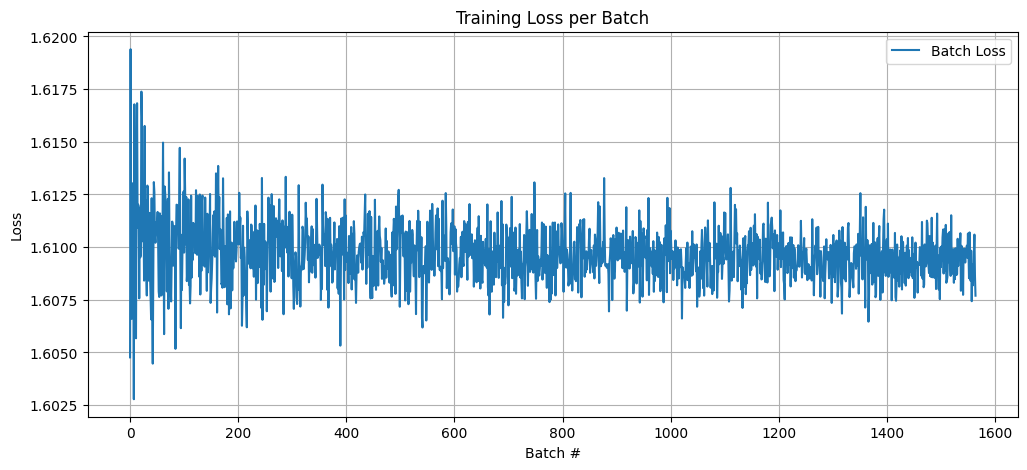

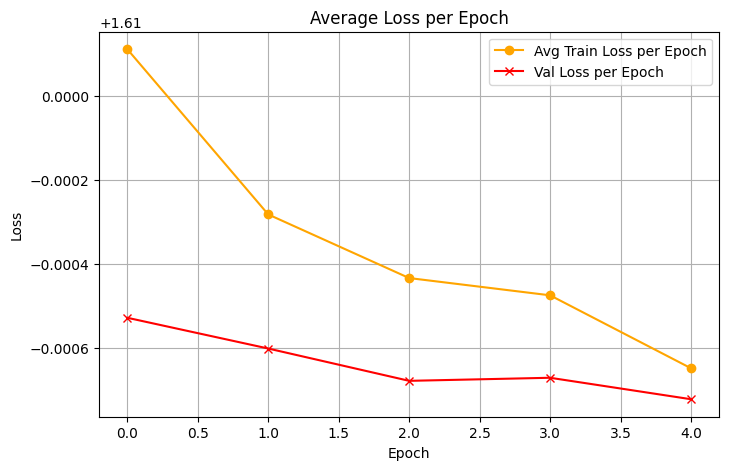

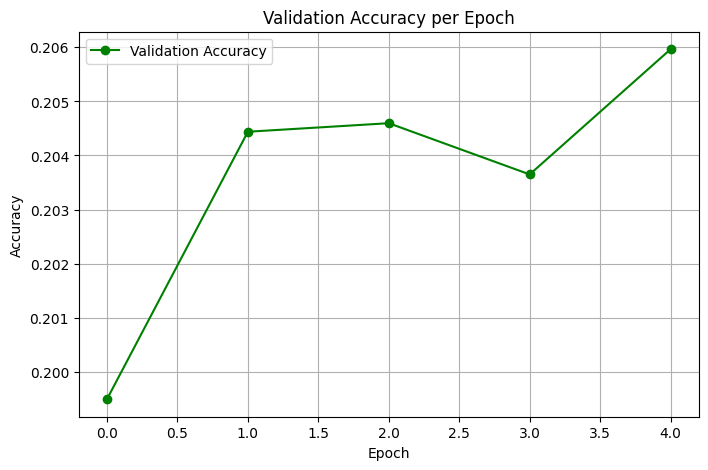

In [16]:
import matplotlib.pyplot as plt
all_losses = metrics["all_batch_losses"]
epoch_losses = metrics["epoch_avg_losses"]
val_losses = metrics["epoch_val_losses"]
accuracies = metrics["epoch_accuracies"]

# Plot all batch-level training losses
plt.figure(figsize=(12, 5))
plt.plot(all_losses, label="Batch Loss")
plt.title("Training Loss per Batch")
plt.xlabel("Batch #")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

# Plot average loss per epoch
plt.figure(figsize=(8, 5))
plt.plot(epoch_losses, marker='o', label="Avg Train Loss per Epoch", color='orange')
plt.plot(val_losses, marker='x', label="Val Loss per Epoch", color='red')
plt.title("Average Loss per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.legend()
plt.show()

# Plot validation accuracy per epoch
plt.figure(figsize=(8, 5))
plt.plot(accuracies, marker='o', label="Validation Accuracy", color='green')
plt.title("Validation Accuracy per Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid(True)
plt.legend()
plt.show()

In [17]:
import torch
import os
from sklearn.metrics import classification_report

# === Define your test dataloader ===
test_dataloader = torch.utils.data.DataLoader(test_dataset, batch_size=256)

# === Define your model parameters (must match training!) ===
def load_model(epoch):
    model = LSTMModel(embedding_matrix, lstm_hidden_size=75, num_lstm_layers=2, bidirectional=True)
    model_path = f"saved_models/model_epoch_{epoch}.pth"
    model.load_state_dict(torch.load(model_path, map_location=torch.device('cpu')))
    model.eval()
    return model

# === Evaluate all saved models ===
for epoch in range(1, 6):
    print(f"\n=== Evaluating model from epoch {epoch} ===")
    model = load_model(epoch)

    y_true, y_pred = [], []

    with torch.no_grad():
        for input_data, length, y in test_dataloader:
            logits = model(input_data, length)
            preds = torch.argmax(logits, dim=1)
            y_true.extend(y.tolist())
            y_pred.extend(preds.tolist())

    print(classification_report(y_true, y_pred, target_names=["1★", "2★", "3★", "4★", "5★"], zero_division=0))



=== Evaluating model from epoch 1 ===
              precision    recall  f1-score   support

          1★       0.24      0.05      0.08       202
          2★       0.00      0.00      0.00       202
          3★       0.11      0.03      0.05       202
          4★       0.19      0.87      0.32       202
          5★       0.00      0.00      0.00       202

    accuracy                           0.19      1010
   macro avg       0.11      0.19      0.09      1010
weighted avg       0.11      0.19      0.09      1010


=== Evaluating model from epoch 2 ===
              precision    recall  f1-score   support

          1★       1.00      0.00      0.01       202
          2★       0.00      0.00      0.00       202
          3★       0.19      0.60      0.29       202
          4★       0.20      0.33      0.25       202
          5★       0.22      0.06      0.09       202

    accuracy                           0.20      1010
   macro avg       0.32      0.20      0.13      1010